In [1]:
import sys
import logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import reduce

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report

import ee
ee.Initialize(project='mapbiomas-india')

# Add parent directory to path to import the module
sys.path.append('..')
from feature_selection.feature_selection_module import EEFeatureSelectionModule

# Embed standardized logging for transparent workflow tracking
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

# Plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['font.size'] = 11

In [2]:
# Load dataset metadata
classwise_samples_scaled_2k_10k = pd.read_csv('data/classwise_samples_scaled_2k_10k.csv')
runs_analysis_df = pd.read_csv('data/groupwise_runs_default_and_scaled_samples.csv')
region_numbers_df = pd.read_csv('data/regions_area.csv')
legends_df = pd.read_csv('data/class_legend.csv')

# Identify the top-performing region from previous analysis
test_region = runs_analysis_df.sort_values(by=['f1_weighted'], ascending=False).iloc[0]
region_code = test_region['region']
region_id = int(region_numbers_df[region_numbers_df['region_code'] == region_code]['region_id'].iloc[0])
sample_version_in = int(test_region['sample_version'])
n_trees = int(test_region['n_trees'])

# Prepare class balancing sample dictionary
balance_samples = list(map(list, dict(zip(
    classwise_samples_scaled_2k_10k['l2_code'],
    classwise_samples_scaled_2k_10k[region_code]
)).items()))

print(f"Selected Region: {region_code} (ID: {region_id})")
print(f"Sample Version: v{sample_version_in} | Random Forest Trees: {n_trees}")

Selected Region: DES (ID: 3)
Sample Version: v7 | Random Forest Trees: 50


In [3]:
sum([y for [x,y] in balance_samples])

7625

In [4]:
# Regional and Temporal Parameters
YEARS = [1995, 2005, 2015, 2024]
# YEARS = [2015]

def drop_collinear_features(df, threshold=0.85):
    """Identifies and drops highly correlated features using Spearman rank correlation."""
    corr_matrix = df.corr(method='spearman').abs()
    # Select upper triangle of correlation matrix
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    # Find features with correlation greater than threshold
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    return to_drop

In [5]:
# Thresholds
CORR_THRESHOLD = 0.85
F1_ELBOW_TOLERANCE = 0.005
MINORITY_FREQ_THRESHOLD = 0.05
MINORITY_SUPPORT_FLOOR = 45
MINORITY_F1_DROP_TOLERANCE = 0.05
STABILITY_RATIO = 0.75

In [ ]:
yearly_metrics = []
stable_features_per_year = {}
feature_ranks_per_year = {}

for yr in YEARS:
    logging.info(f"====== PROCESSING TEMPORAL SNAPSHOT: {yr} ======")
    
    selector = EEFeatureSelectionModule(region_id=region_id, year=yr, sample_version_in=sample_version_in, number_of_trees=n_trees)
    _ = selector.load_and_balance_data(balance_samples=balance_samples)
    
    if selector.training_partition.size().getInfo() == 0:
        logging.error(f"No training samples found for {yr}. Skipping.")
        continue
        
    drop_props = ee.List(['random', 'system:index', 'new_id', 'year', 'class', 'area_m2', 'area_proportion'])
    all_bands = ee.List(selector.training_partition.first().propertyNames()).removeAll(drop_props).getInfo()
    
    logging.info("Downloading data...")
    try:
        url = selector.training_partition.getDownloadURL(filetype='csv', selectors=all_bands + ['class'])
        df = pd.read_csv(url)
    except Exception:
        sampled = selector.training_partition.select(all_bands + ['class']).limit(5000).getInfo()
        df = pd.DataFrame([feat['properties'] for feat in sampled['features']])
        
    X = df.drop(columns=['class', 'system:index'], errors='ignore')
    y = df['class']
    
    # 1. Handle Multicollinearity
    collinear_to_drop = drop_collinear_features(X, threshold=CORR_THRESHOLD)
    X_filtered = X.drop(columns=collinear_to_drop)
    
    # 2. Dynamic Minority Class Extraction
    class_freq = y.value_counts(normalize=True)
    class_counts = y.value_counts()
    minority_classes = class_freq[(class_freq < MINORITY_FREQ_THRESHOLD) & (class_counts >= MINORITY_SUPPORT_FLOOR)].index.tolist()
    logging.info(f"Protected minority classes: {minority_classes}")

    # 3. RFECV (Optimized for Macro F1)
    rf = RandomForestClassifier(n_estimators=n_trees,min_samples_leaf = 5, random_state=42, n_jobs=-1)
    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    rfecv = RFECV(estimator=rf, step=1, cv=cv, scoring='f1_macro', n_jobs=-1)
    rfecv.fit(X_filtered, y)
    
    # 4. Elbow Extraction
    cv_scores = rfecv.cv_results_['mean_test_score']
    n_features_grid = np.arange(1, len(cv_scores) + 1)
    max_score = cv_scores.max()
    tolerance_threshold = max_score - F1_ELBOW_TOLERANCE
    
    optimal_n_features = n_features_grid[np.where(cv_scores >= tolerance_threshold)[0][0]]
    rank_1_features = X_filtered.columns[rfecv.support_]
    
    if optimal_n_features == rfecv.n_features_:
        proposed_features = rank_1_features.tolist()
    else:
        elbow_df = pd.DataFrame({'band': rank_1_features, 'importance': rfecv.estimator_.feature_importances_})
        elbow_df = elbow_df.sort_values(by='importance', ascending=False)
        proposed_features = elbow_df.head(optimal_n_features)['band'].tolist()

    # 5. Minority Revert Trigger
    revert_triggered = False
    if minority_classes:
        y_pred_max = cross_val_predict(rf, X_filtered[rank_1_features], y, cv=3, n_jobs=-1)
        report_max = classification_report(y, y_pred_max, output_dict=True)
        
        y_pred_elbow = cross_val_predict(rf, X_filtered[proposed_features], y, cv=3, n_jobs=-1)
        report_elbow = classification_report(y, y_pred_elbow, output_dict=True)
        
        for cls in minority_classes:
            cls_str = str(cls)
            if cls_str in report_max and cls_str in report_elbow:
                drop = report_max[cls_str]['f1-score'] - report_elbow[cls_str]['f1-score']
                if drop > MINORITY_F1_DROP_TOLERANCE:
                    logging.warning(f"Class {cls} F1 dropped by {drop:.4f}. REVERTING to Max Features.")
                    revert_triggered = True
                    break

    final_features = rank_1_features.tolist() if revert_triggered else proposed_features
    stable_features_per_year[yr] = final_features
    
    # Record custom ranks & metrics
    ranks = pd.DataFrame({'band': X_filtered.columns, f'rank_{yr}': rfecv.ranking_})
    ranks.loc[ranks['band'].isin(final_features), f'rank_{yr}'] = 1
    ranks.loc[(ranks[f'rank_{yr}'] == 1) & (~ranks['band'].isin(final_features)), f'rank_{yr}'] = 2
    feature_ranks_per_year[yr] = ranks
    
    rf_final = RandomForestClassifier(n_estimators=n_trees,min_samples_leaf = 5, random_state=42, n_jobs=-1)
    y_pred_final = cross_val_predict(rf_final, X_filtered[final_features], y, cv=3, n_jobs=-1)
    final_report = classification_report(y, y_pred_final, output_dict=True)
    
    yearly_metrics.append({
        'Year': yr, 
        'Macro F1': final_report['macro avg']['f1-score'], 
        'Accuracy': final_report['accuracy'],
        'Feature Count': len(final_features)
    })

2026-08-19 23:13:15,800 - INFO - ====== PROCESSING TEMPORAL SNAPSHOT: 1995 ======


Calculating Level 1 class distributions (this may take a moment)...


2026-08-19 23:14:31,506 - INFO - Downloading data...
2026-08-19 23:15:35,945 - INFO - Protected minority classes: [14, 33, 11, 76]
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it pos

Calculating Level 1 class distributions (this may take a moment)...


2026-08-19 23:20:14,148 - INFO - Downloading data...
2026-08-19 23:21:12,950 - INFO - Protected minority classes: [14, 11, 33, 76]
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it pos

Calculating Level 1 class distributions (this may take a moment)...


2026-08-19 23:25:07,526 - INFO - Downloading data...
2026-08-19 23:25:56,235 - INFO - Protected minority classes: [14, 11, 33, 76]
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/nirzaree/Code/GitClones/IOLN/.IOLN/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it pos

Calculating Level 1 class distributions (this may take a moment)...


2026-08-19 23:29:44,000 - INFO - Downloading data...
2026-08-19 23:30:41,275 - INFO - Protected minority classes: [14, 33, 11, 76]


In [8]:
# Aggregate ranks
rank_dfs = list(feature_ranks_per_year.values())
master_rank_df = reduce(lambda left, right: pd.merge(left, right, on='band', how='outer'), rank_dfs)

# Dynamic Proportional Threshold
total_years = len(YEARS)
min_years_required = int(np.ceil(total_years * STABILITY_RATIO))

selected_masks = master_rank_df.filter(like='rank_') == 1
master_rank_df['years_selected'] = selected_masks.sum(axis=1)

stable_features = master_rank_df[master_rank_df['years_selected'] >= min_years_required]['band'].tolist()
near_miss_features = master_rank_df[master_rank_df['years_selected'] == (min_years_required - 1)]['band'].tolist()

print("=" * 60)
print(f" TEMPORALLY STABLE FEATURES ({region_id} | Threshold: {min_years_required}/{total_years})")
print("=" * 60)
print(stable_features)
print("-" * 60)
print(f"NEAR-MISS FEATURES: {near_miss_features}")
print("=" * 60)

 TEMPORALLY STABLE FEATURES (3 | Threshold: 3/4)
['cai_median', 'cai_median_dry', 'cai_stdDev', 'cloud_amp', 'cloud_median', 'gvs_amp', 'ndwi_median', 'ndwi_median_dry', 'nir_median', 'nir_median_dry', 'npv_median', 'npv_median_wet', 'pri_median', 'pri_median_dry', 'red_min', 'savi_median_wet', 'shade_median_wet', 'slope', 'soil_median_dry', 'swir2_min', 'wefi_amp']
------------------------------------------------------------
NEAR-MISS FEATURES: ['blue_stdDev', 'green_median_texture', 'ndvi_stdDev', 'nir_median_wet', 'nir_min', 'npv_min', 'pri_median_wet', 'sefi_stdDev', 'shade_median_dry', 'swir1_stdDev']


In [12]:
rank_dfs

[                    band  rank_1995
 0        soil_median_dry          1
 1         gvs_median_dry         11
 2             cai_stdDev          1
 3       shade_median_dry          1
 4        savi_median_wet          1
 5         pri_median_dry          2
 6            ndvi_stdDev          1
 7              swir2_min          1
 8         npv_median_wet          1
 9             npv_stdDev         10
 10              wefi_amp          1
 11               gvs_amp          1
 12          shade_stdDev          9
 13            cai_median          1
 14             cloud_amp          1
 15          cloud_median          1
 16            nir_median          1
 17            gvs_median          2
 18                 slope          1
 19               npv_max          1
 20               npv_min          7
 21            nir_stdDev          8
 22          swir1_stdDev          6
 23              soil_amp          4
 24      shade_median_wet          3
 25           sefi_stdDev          2
 

In [11]:
master_rank_df

,band,rank_1995,rank_2005,rank_2015,rank_2024,years_selected
0,blue_median_dry,NaN,NaN,NaN,1.0,1
1,blue_stdDev,1.0,1.0,NaN,NaN,2
2,cai_median,1.0,1.0,1.0,1.0,4
3,cai_median_dry,1.0,1.0,1.0,1.0,4
4,cai_stdDev,1.0,1.0,1.0,1.0,4
5,cloud_amp,1.0,1.0,1.0,2.0,3
6,cloud_max,NaN,NaN,NaN,1.0,1
7,cloud_median,1.0,1.0,1.0,1.0,4
8,green_median_texture,1.0,2.0,1.0,2.0,2
9,gv_min,12.0,5.0,NaN,NaN,0


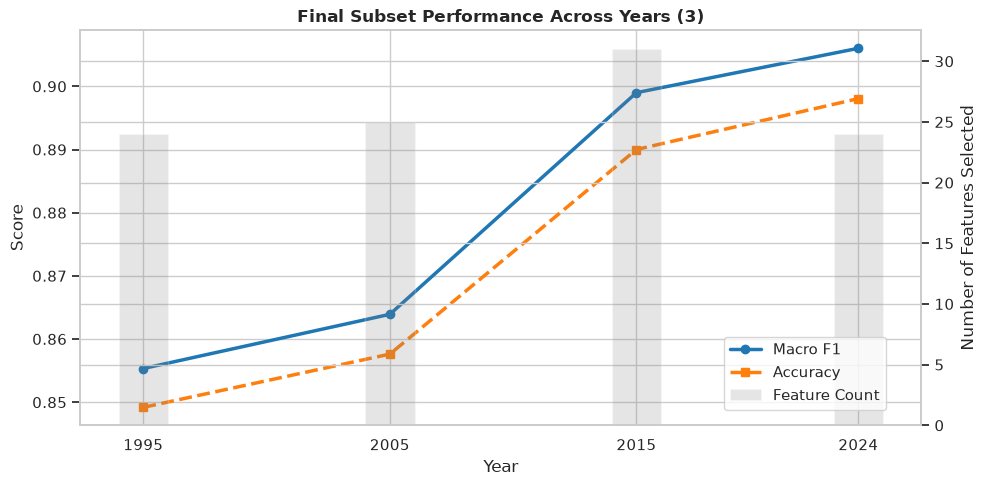

/tmp/ipykernel_47194/1189682319.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=plot_data, x='years_selected', y='band', palette='Blues_r')


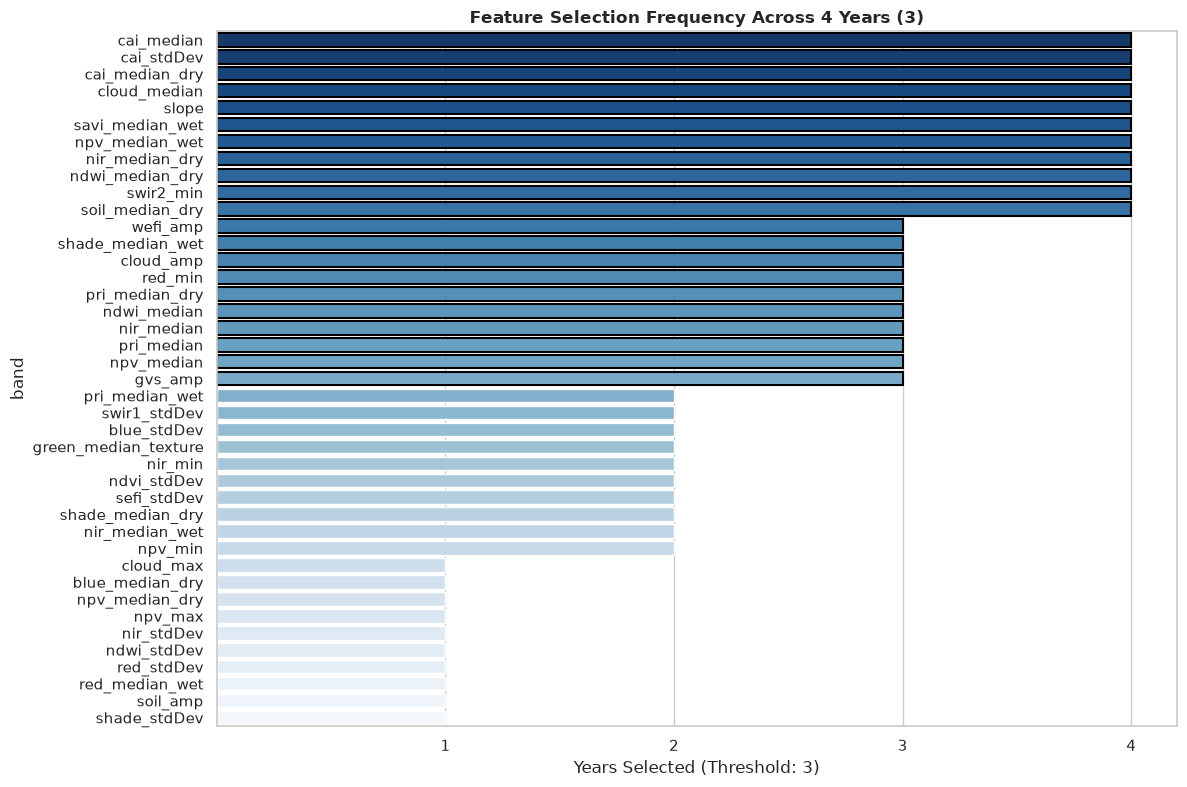

In [9]:
metrics_df = pd.DataFrame(yearly_metrics)

# 1. Performance Plot
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(metrics_df['Year'], metrics_df['Macro F1'], marker='o', linewidth=2.5, label='Macro F1', color='#1f77b4')
ax1.plot(metrics_df['Year'], metrics_df['Accuracy'], marker='s', linewidth=2.5, linestyle='--', label='Accuracy', color='#ff7f0e')
ax1.set_xlabel('Year')
ax1.set_ylabel('Score')
ax1.set_xticks(YEARS)
ax1.set_title(f'Final Subset Performance Across Years ({region_id})', fontweight='bold')

ax2 = ax1.twinx()
ax2.bar(metrics_df['Year'], metrics_df['Feature Count'], alpha=0.2, color='grey', width=2, label='Feature Count')
ax2.set_ylabel('Number of Features Selected')
fig.legend(loc='lower right', bbox_to_anchor=(0.9, 0.15))
plt.tight_layout()
plt.show()

# 2. Stability Plot
plt.figure(figsize=(12, 8))
plot_data = master_rank_df[master_rank_df['years_selected'] > 0].sort_values(by='years_selected', ascending=False)
ax = sns.barplot(data=plot_data, x='years_selected', y='band', palette='Blues_r')
plt.title(f'Feature Selection Frequency Across {total_years} Years ({region_id})', fontweight='bold')
plt.xlabel(f'Years Selected (Threshold: {min_years_required})')
plt.xticks(range(1, total_years + 1))

for p in ax.patches:
    if p.get_width() >= min_years_required:
        p.set_edgecolor('black')
        p.set_linewidth(1.5)

plt.tight_layout()
plt.show()

In [10]:
metrics_df.to_csv('data/feature_importance_multiyear_region3_rfe_refined.csv',index=False)

In [ ]:
metrics_df = pd.DataFrame(yearly_metrics)

# 1. Performance Plot
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.plot(metrics_df['Year'], metrics_df['Macro F1'], marker='o', linewidth=2.5, label='Macro F1', color='#1f77b4')
ax1.plot(metrics_df['Year'], metrics_df['Accuracy'], marker='s', linewidth=2.5, linestyle='--', label='Accuracy', color='#ff7f0e')
ax1.set_xlabel('Year')
ax1.set_ylabel('Score')
ax1.set_xticks(YEARS)
ax1.set_title(f'Final Subset Performance Across Years ({REGION_CODE})', fontweight='bold')

ax2 = ax1.twinx()
ax2.bar(metrics_df['Year'], metrics_df['Feature Count'], alpha=0.2, color='grey', width=2, label='Feature Count')
ax2.set_ylabel('Number of Features Selected')
fig.legend(loc='lower right', bbox_to_anchor=(0.9, 0.15))
plt.tight_layout()
plt.show()

# 2. Stability Plot
plt.figure(figsize=(12, 8))
plot_data = master_rank_df[master_rank_df['years_selected'] > 0].sort_values(by='years_selected', ascending=False)
ax = sns.barplot(data=plot_data, x='years_selected', y='band', palette='Blues_r')
plt.title(f'Feature Selection Frequency Across {total_years} Years ({REGION_CODE})', fontweight='bold')
plt.xlabel(f'Years Selected (Threshold: {min_years_required})')
plt.xticks(range(1, total_years + 1))

for p in ax.patches:
    if p.get_width() >= min_years_required:
        p.set_edgecolor('black')
        p.set_linewidth(1.5)

plt.tight_layout()
plt.show()

In [ ]:
# 1. Combine ranks across all evaluated years
rank_dfs = list(feature_ranks_per_year.values())
master_rank_df = reduce(lambda left, right: pd.merge(left, right, on='band', how='outer'), rank_dfs)

# 2. GENERALIZED STABILITY LOGIC
STABILITY_RATIO = 0.75  # Feature must be optimal in at least 75% of the years
total_years_tested = len(YEARS)
min_years_required = int(np.ceil(total_years_tested * STABILITY_RATIO))

logging.info(f"Requiring features to be selected in at least {min_years_required} out of {total_years_tested} years.")

# Calculate selection frequency (Count how many times a feature achieved Rank 1)
selected_masks = master_rank_df.filter(like='rank_') == 1
master_rank_df['years_selected'] = selected_masks.sum(axis=1)

# Extract features meeting the dynamic threshold
temporally_stable_features = master_rank_df[
    master_rank_df['years_selected'] >= min_years_required
]['band'].tolist()

print("=" * 60)
print(f" TEMPORALLY STABLE FEATURES ({region_id})")
print("=" * 60)
print(f"Total Features: {len(temporally_stable_features)}")
print(temporally_stable_features)
print("=" * 60)

In [ ]:
# Identify runner-up features (missed the dynamic threshold by exactly 1 year)
runner_up_threshold = min_years_required - 1
runner_up_features = master_rank_df[
    master_rank_df['years_selected'] == runner_up_threshold
]['band'].tolist()

print("=" * 60)
print(f" NEAR-MISS FEATURES (Selected in {runner_up_threshold} years)")
print("=" * 60)
print(runner_up_features)
print("=" * 60)

In [ ]:
# 3. Dynamic Plotting
plt.figure(figsize=(12, 8))
plot_data = master_rank_df[master_rank_df['years_selected'] > 0].sort_values(by='years_selected', ascending=False)

ax = sns.barplot(data=plot_data, x='years_selected', y='band', palette='Blues_r')
plt.title(f'Temporal Feature Stability - Selection Frequency Across {total_years_tested} Years ({region_id})', fontsize=14, fontweight='bold')
plt.xlabel(f'Number of Years Selected as Optimal (Threshold: {min_years_required})')
plt.ylabel('Feature Band')
plt.xticks(range(1, total_years_tested + 1)) # Dynamic X-axis

# Dynamically highlight features meeting the threshold
for p in ax.patches:
    if p.get_width() >= min_years_required:
        p.set_edgecolor('black')
        p.set_linewidth(1.5)

plt.tight_layout()
plt.show()

In [ ]:
master_rank_df[master_rank_df['years_selected'] == 4].shape

In [ ]:
master_rank_df

In [ ]:
master_rank_df.T.count(axis=1) 

In [ ]:
X.shape

In [ ]:
# master_rank_df.to_csv('data/feature_importance_multiyear_region3_rfe.csv', index=False)

Elbow method RFE

In [ ]:
# 5. Extract Results and Find the "Elbow"
cv_scores = rfecv.cv_results_['mean_test_score']
n_features_grid = np.arange(1, len(cv_scores) + 1) # Assumes min_features_to_select=1 and step=1

max_score = cv_scores.max()
tolerance_threshold = max_score - 0.005

# Identify the smallest subset size that crosses the acceptable threshold
valid_indices = np.where(cv_scores >= tolerance_threshold)[0]
optimal_n_features = n_features_grid[valid_indices[0]]

logging.info(f"Absolute max F1: {max_score:.4f} ({rfecv.n_features_} features)")
logging.info(f"Elbow threshold (Max - 0.005): {tolerance_threshold:.4f}")
logging.info(f"Selected elbow subset size: {optimal_n_features} features")

# 6. Slice the Feature Subset
if optimal_n_features == rfecv.n_features_:
    # Absolute maximum is the elbow
    final_features = X_filtered.columns[rfecv.support_].tolist()
else:
    # Sub-rank the Rank 1 block using the fitted estimator's importances
    rank_1_features = X_filtered.columns[rfecv.support_]
    rank_1_importances = rfecv.estimator_.feature_importances_
    
    elbow_df = pd.DataFrame({
        'band': rank_1_features,
        'importance': rank_1_importances
    }).sort_values(by='importance', ascending=False)
    
    # Extract only the top 'optimal_n_features'
    final_features = elbow_df.head(optimal_n_features)['band'].tolist()

stable_features_per_year[yr] = final_features

# Store standard RFE ranks for aggregation tracking
ranks = pd.DataFrame({'band': X_filtered.columns, f'rank_{yr}': rfecv.ranking_})

# Force the sliced features to Rank 1, and demote the dropped Rank 1 features to Rank 2
ranks.loc[ranks['band'].isin(final_features), f'rank_{yr}'] = 1
ranks.loc[(ranks[f'rank_{yr}'] == 1) & (~ranks['band'].isin(final_features)), f'rank_{yr}'] = 2

feature_ranks_per_year[yr] = ranks

In [ ]:
feature_ranks_per_year